In [1]:
!pip install skimpy

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.1 MB 4.2 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/13.1 MB 2.7 MB/s eta 0:00:05
   ---- ----------------------------------- 1.6/13.1 MB 2.6 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/13.1 MB 2.6 MB/s eta 0:00:05
   -------- ------------------------------- 2.6/13.1 MB 2.7 MB/s eta 0:00:04
   ---------- ----------------------------- 3.4/13.1 MB 2.8 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/13.1 MB 2.8 MB/s eta 0:00:04
   -------------- ------------------------- 4.7/13.1 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 5.5/13.1 MB 2.9 MB/s eta 0:00:03
   ------------------ --------------------- 6.0/13.1 MB 2.9 MB/s eta 0:00:03
   -------------------- ------------------- 6.6/13.1 MB 2.9 MB/s eta 0:00:03
   --------------------- ------------------ 7.1/13.1 MB 2.8 MB/s eta 0:00:03
   ---

In [10]:
from sklearn.utils import resample
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, silhouette_score,f1_score,recall_score,precision_score
from sklearn.model_selection import train_test_split, GridSearchCV
### Algorithams
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
## visualzations and summary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
from skimpy import skim
warnings.filterwarnings('ignore')

In [12]:
# Load the dataset
file_path = r'dataset.csv'
data = pd.read_csv(file_path)

In [15]:
#display the first 5 rows
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [17]:
#display the last 5 rows
data.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [19]:
skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 6362620 │ │ float64     │ 5     │                                                         │
│ │ Number of columns │ 11      │ │ int64       │ 3     │                                                         │
│ └───────────────────┴─────────┘ │ string      │ 3     │                                                         │
│                                 └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA  ┃ NA %  ┃ mean       ┃ sd       ┃ p0 ┃ p25   ┃ p50    ┃ p75     ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ step            │   0 │     0 │      243.4 │    142.3 │  1 │   156 │    239 │     335 │       743 │ ▅▇▇▃▁  │  │
│ │ amount          │   0 │     0 │     179900 │   603900 │  0 │ 13390 │  74870 │  208700 │  92450000 │   ▇    │  │
│ │ oldbalanceOrg   │   0 │     0 │     833900 │  2888000 │  0 │     0 │  14210 │  107300 │  59590000 │   ▇    │  │
│ │ newbalanceOrig  │   0 │     0 │     855100 │  2924000 │  0 │     0 │      0 │  144300 │  49590000 │   ▇    │  │
│ │ oldbalanceDest  │   0 │     0 │    1101000 │  3399000 │  0 │     0 │ 132700 │  943000 │ 356000000 │   ▇    │  │
│ │ newbalanceDest  │   0 │     0 │    1225000 │  3674000 │  0 │     0 │ 214700 │ 1112000 │ 356200000 │   ▇    │  │
│ │ isFraud         │   0 │     0 │   0.001291 │   0.0359 │  0 │     0 │      0 │       0 │         1 │   ▇    │  │
│ │ isFlaggedFraud  │   0 │     0 │  2.515e-06 │ 0.001586 │  0 │     0 │      0 │       0 │         1 │   ▇    │  │
│ └─────────────────┴─────┴───────┴────────────┴──────────┴────┴───────┴────────┴─────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃          ┃    ┃      ┃          ┃            ┃           ┃            ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column   ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min       ┃ max        ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ type     │  0 │    0 │ DEBIT    │ TRANSFER   │ CASH_IN   │ TRANSFER   │      7.42 │          1 │   6362620 │  │
│ │ nameOrig │  0 │    0 │ C6626    │ C123100681 │ C10000006 │ C999999784 │      10.5 │          1 │   6362620 │  │
│ │          │    │      │          │ 5          │ 39        │            │           │            │           │  │
│ │ nameDest │  0 │    0 │ C2       │ M197978715 │ C10000040 │ M999999784 │      10.5 │          1 │   6362620 │  │
│ │          │    │      │          │ 5          │ 82        │            │           │            │           │  │
│ └──────────┴────┴──────┴──────────┴────────────┴───────────┴────────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [21]:
# data's row, column counts
data.shape

(6362620, 11)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [25]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [27]:
# # plot the line plot to show the missing values
# plt.figure(figsize=(20,5))
# sns.heatmap( data.isnull(),yticklabels=False,cbar=True,cmap='viridis')
# plt.gcf().set_facecolor('purple')
# plt.show()

<Axes: >

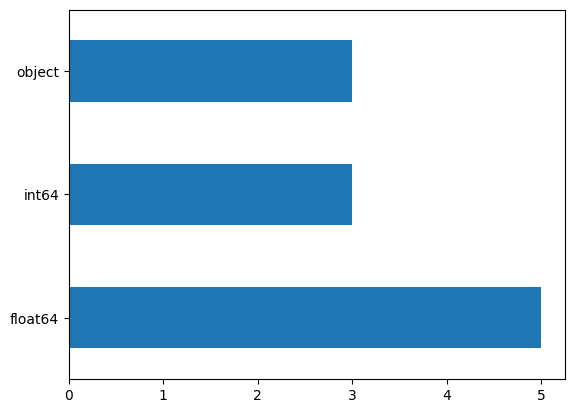

In [29]:
data.dtypes.value_counts().plot(kind='barh')

In [31]:
# checking the datatypes of the columns
data.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [33]:
# Drop rows with missing values (if any)
data = data.dropna()

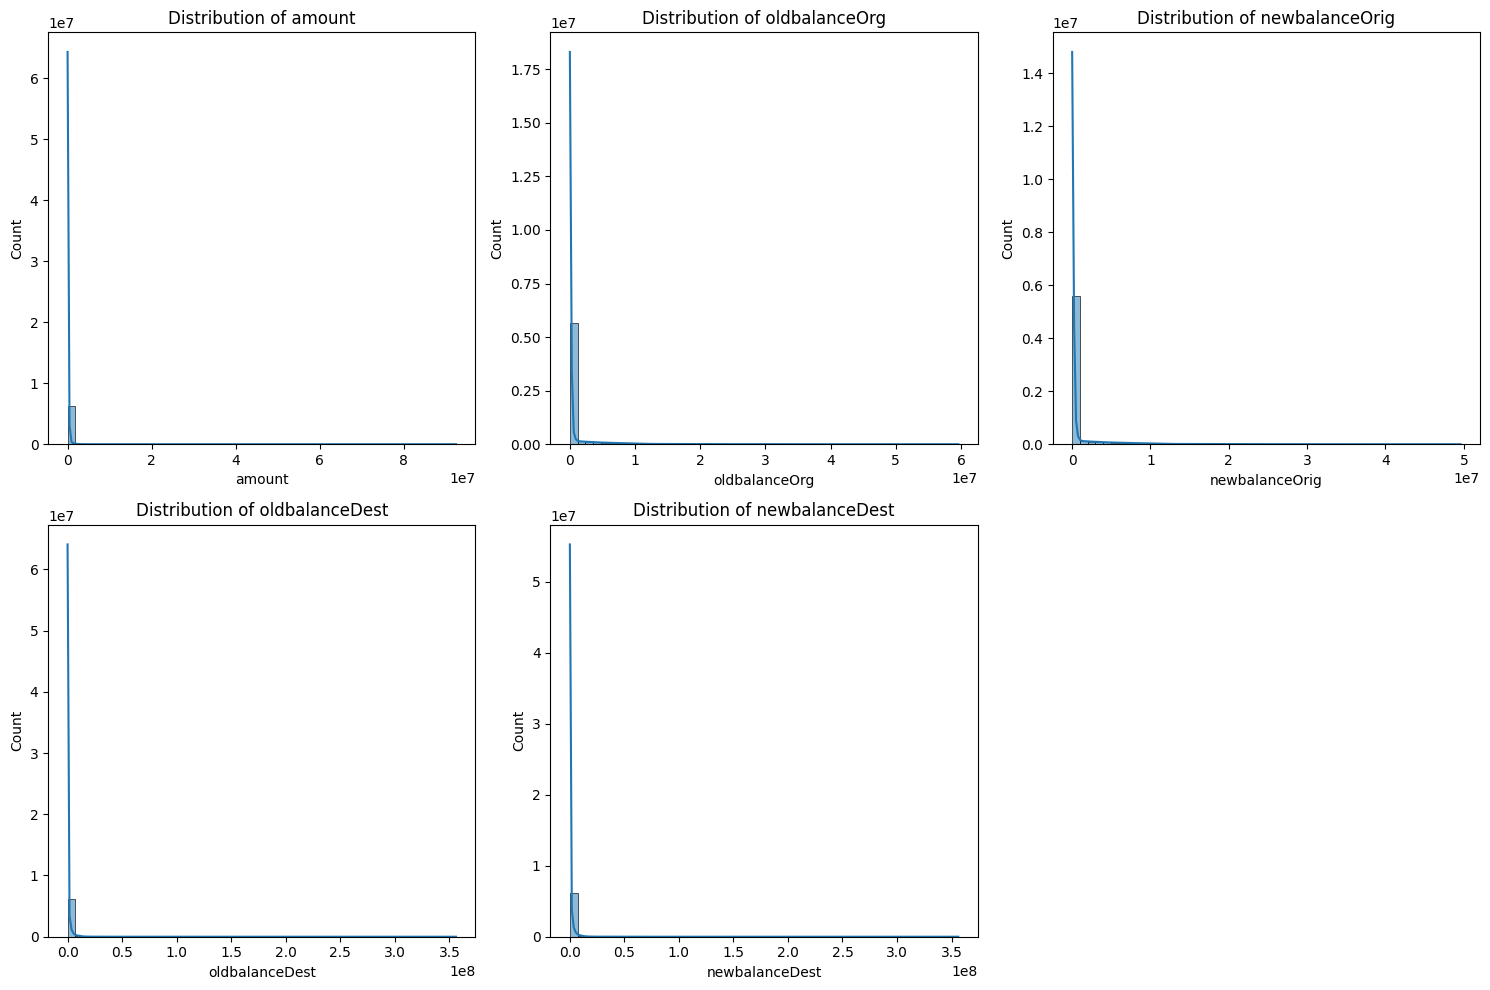

In [35]:
# Plot distributions of numerical features
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[feature], bins=50, kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Transaction Type')

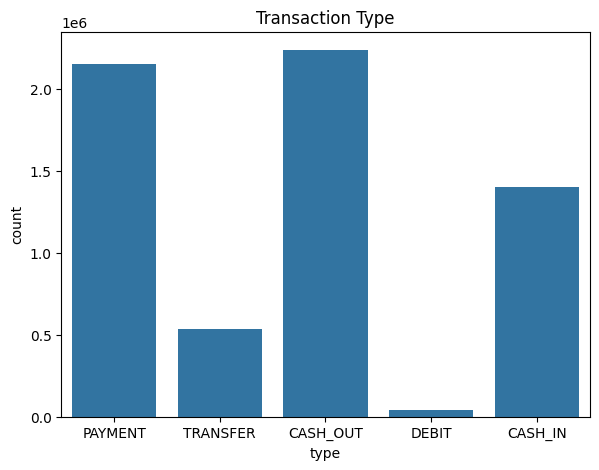

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of categorical features
plt.figure(figsize=(15, 5))

# Transaction type
plt.subplot(1, 2, 1)
sns.countplot(x='type', data=data)
plt.title('Transaction Type')

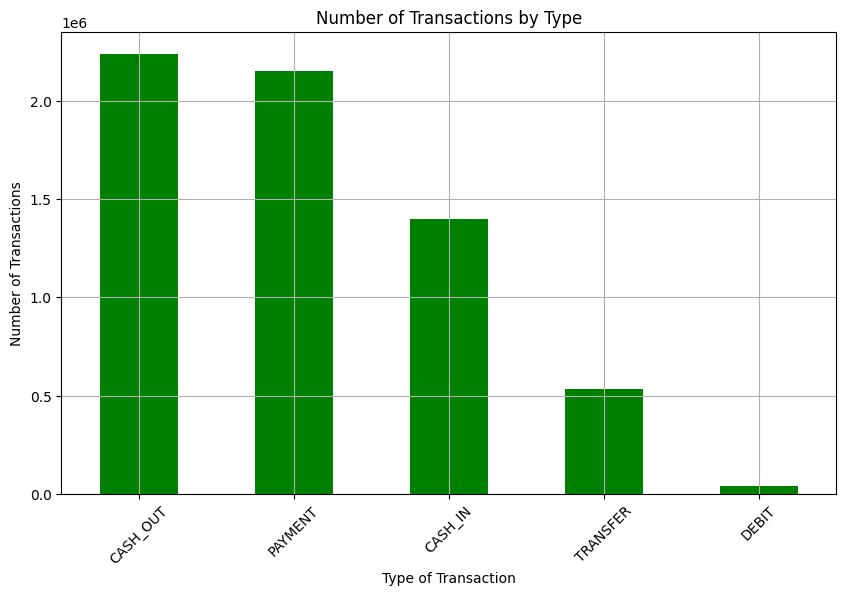

In [39]:

# Counting the occurrence of each transaction type
transaction_types = data['type'].value_counts()

plt.figure(figsize=(10, 6))
transaction_types.plot(kind='bar', color='green')
plt.title('Number of Transactions by Type')
plt.xlabel('Type of Transaction')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

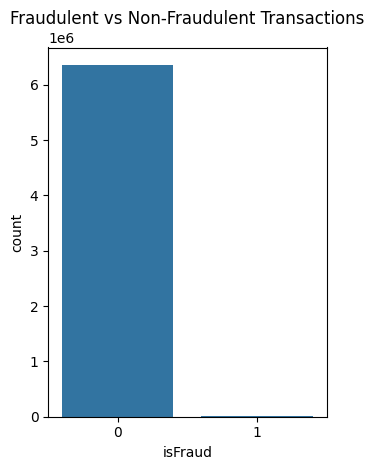

In [41]:
# Fraudulent vs Non-Fraudulent Transactions
plt.subplot(1, 2, 2)
sns.countplot(x='isFraud', data=data)
plt.title('Fraudulent vs Non-Fraudulent Transactions')

plt.tight_layout()
plt.show()

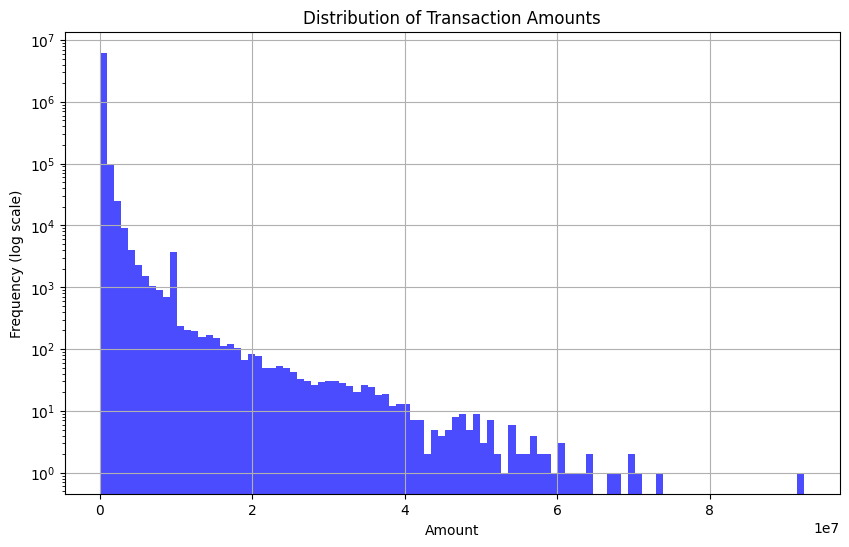

In [43]:
# Assuming your DataFrame is named df
plt.figure(figsize=(10, 6))
plt.hist(data['amount'], bins=100, color='blue', alpha=0.7)
plt.yscale('log')  
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency (log scale)')
plt.grid(True)
plt.show()

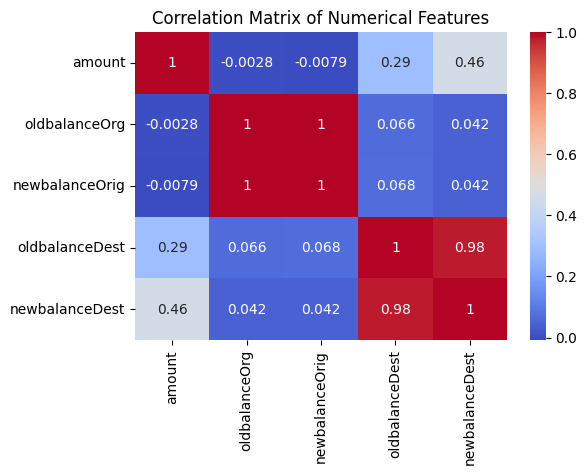

In [45]:
# Correlation matrix
plt.figure(figsize=(6, 4))
correlation_matrix = data[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

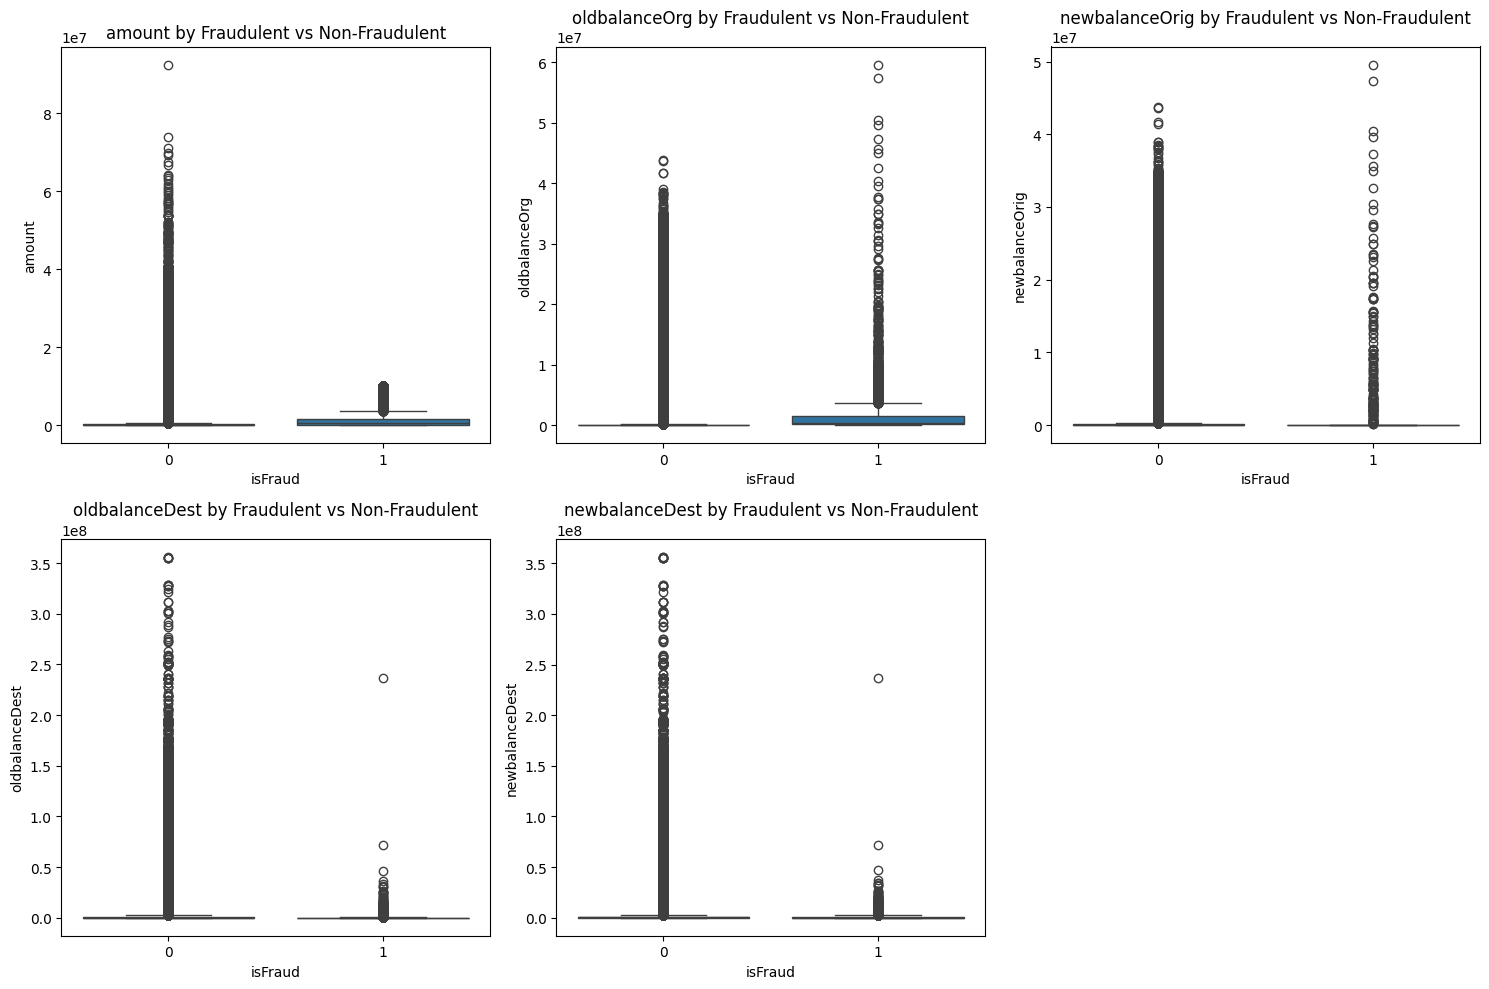

In [47]:
# Boxplots for numerical features with respect to isFraud
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='isFraud', y=feature, data=data)
    plt.title(f'{feature} by Fraudulent vs Non-Fraudulent')

plt.tight_layout()
plt.show()

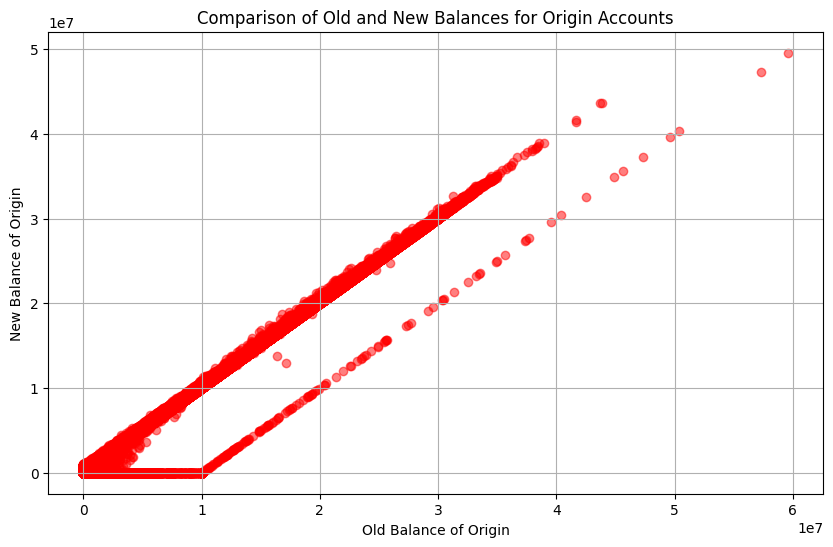

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(data['oldbalanceOrg'], data['newbalanceOrig'], alpha=0.5, color='red')
plt.title('Comparison of Old and New Balances for Origin Accounts')
plt.xlabel('Old Balance of Origin')
plt.ylabel('New Balance of Origin')
plt.grid(True)
plt.show()

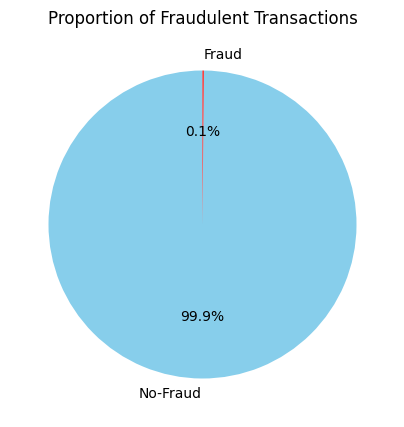

In [51]:
# Counting fraud and non-fraud transactions
fraud_counts = data['isFraud'].value_counts()

plt.figure(figsize=(5, 5))
fraud_counts.plot(kind='pie', labels=['No-Fraud', 'Fraud'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'red'])
plt.title('Proportion of Fraudulent Transactions')
plt.ylabel('')  # Hide the y-label as it's not needed for pie charts
plt.show()

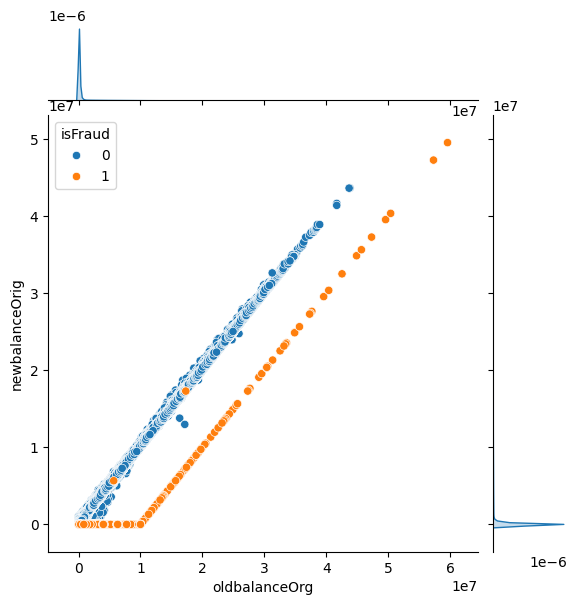

In [53]:
sns.jointplot(data=data, x="oldbalanceOrg", y="newbalanceOrig", hue="isFraud")

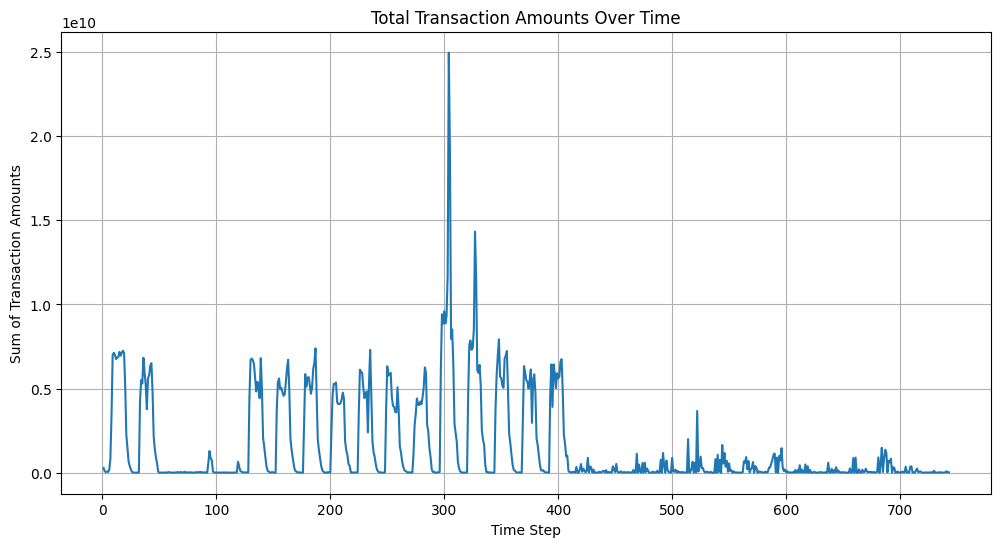

In [55]:
plt.figure(figsize=(12, 6))
data.groupby('step')['amount'].sum().plot()
plt.title('Total Transaction Amounts Over Time')
plt.xlabel('Time Step')
plt.ylabel('Sum of Transaction Amounts')
plt.grid(True)
plt.show()

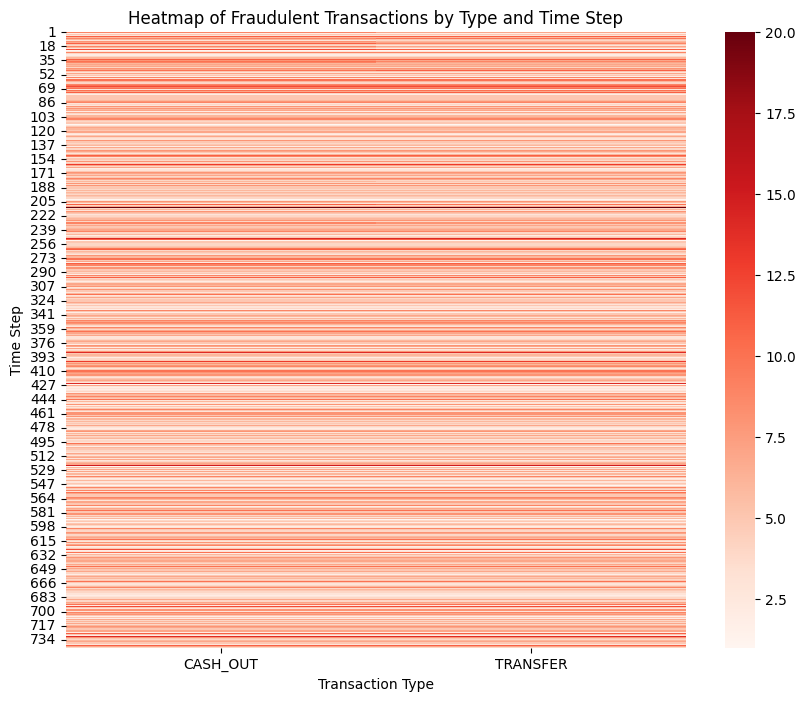

In [57]:
# Creating a pivot table with counts of fraud transactions per type and step
fraud_data = data[data['isFraud'] == 1]
pivot_table = pd.pivot_table(fraud_data, values='isFraud', index='step', columns='type', aggfunc='count', fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=False, cmap='Reds')
plt.title('Heatmap of Fraudulent Transactions by Type and Time Step')
plt.xlabel('Transaction Type')
plt.ylabel('Time Step')
plt.show()

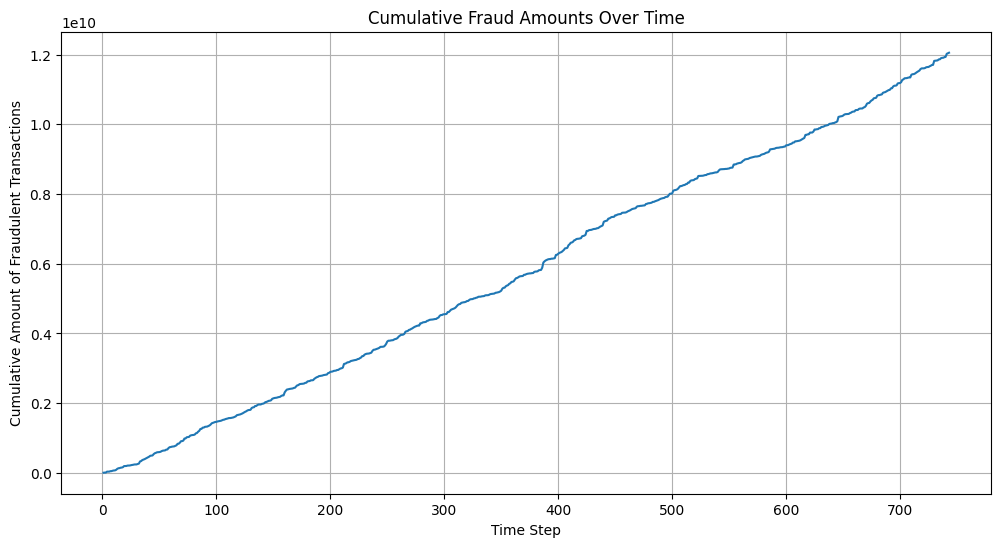

In [59]:
# Creating a cumulative sum of amounts only for fraud cases
fraud_amounts_cumulative = data[data['isFraud'] == 1].groupby('step')['amount'].sum().cumsum()

plt.figure(figsize=(12, 6))
fraud_amounts_cumulative.plot()
plt.title('Cumulative Fraud Amounts Over Time')
plt.xlabel('Time Step')
plt.ylabel('Cumulative Amount of Fraudulent Transactions')
plt.grid(True)
plt.show()

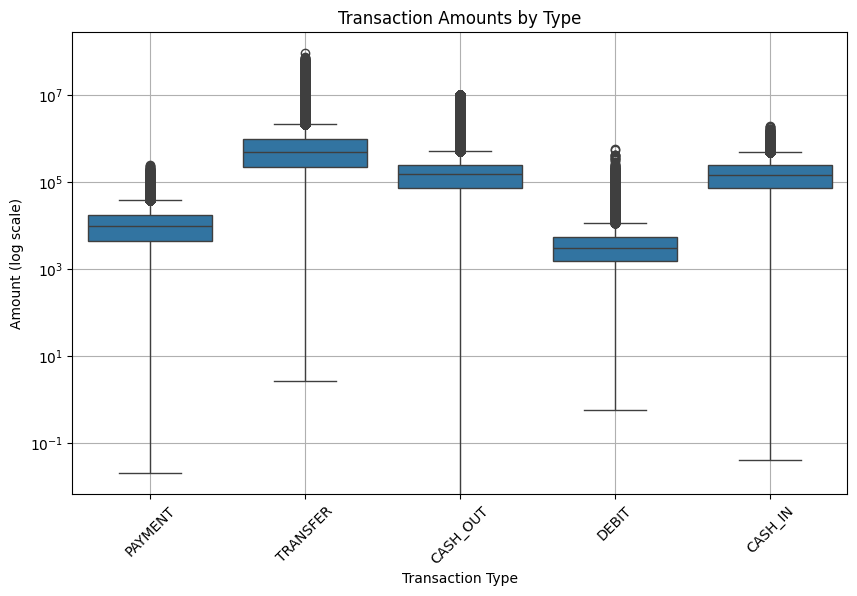

In [61]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='amount', data=data)
plt.yscale('log')  # Using a log scale due to wide distribution of amounts
plt.title('Transaction Amounts by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Amount (log scale)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

<Axes: ylabel='count'>

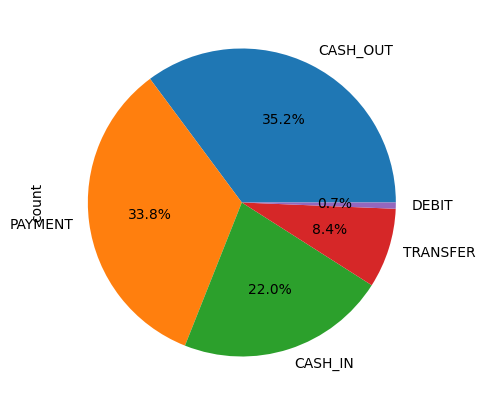

In [63]:
# plot the pie plot for the
plt.figure(figsize=(10,5))
data['type'].value_counts().plot.pie(autopct='%1.1f%%')

In [65]:
# Separate the majority and minority classes
data_majority = data[data.isFraud == 0]
data_minority = data[data.isFraud == 1]

In [67]:
# Undersample the majority class
data_majority_undersampled = resample(data_majority, 
                                      replace=False,     # sample without replacement
                                      n_samples=len(data_minority),    # to match minority class
                                      random_state=42)   # reproducible results

# Combine the undersampled majority class with the minority class
data_undersampled = pd.concat([data_majority_undersampled, data_minority])

In [ ]:
sa